# 💫 Kuramoto Solver Accuracy & Symmetry Benchmark
This notebook  automates the validation process for the `Kuramoto Benchmark Suite`. It evaluates the accuracy of the fixed-step `euler` and experimental Geometric Algebra `rotor` solvers against the adaptive `rk45` ground truth, and tracks the breakdown of conserved quantities (Noether charges).

In [1]:
import json
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

## 🛠️ 1. Setup Configureation & Outputs
Define a baseline configuration and create a dedicated directory for benchmark data outputs.

In [2]:
os.makedirs('data/benchmark', exist_ok=True)

base_config = {
    "n_oscillators": 50,
    "coupling_strength": 1.5,
    "topology": "complete",
    "timesteps": 2000,
    "dt": 0.05,
    "seed": 27,
    "frequency_distribution": {
        "type": "normal",
        "mean": 0.0,
        "std": 1.0
    }
}

with open ('data/benchmark/config.json', 'w') as f:
    json.dump(base_config, f, indent=2)
print("✔️ Base configuration file generated successfully!")

✔️ Base configuration file generated successfully!


## 👟 2. Run Multi-Solver Batch Simulations
Sweep across solvers (`rk45`, `euler`, `rotor`) using default time-step ($dt=0.05$), enabling `--track-symmetries` to capture the Lie symmetry metrics.

In [3]:
solvers = ['rk45', 'euler', 'rotor']

for solver in solvers:
    print(f"👟 Running simulation for solver: {solver}...")
    cmd = [
        'kuramoto', 'generate',
        '--config', 'data/benchmark/config.json',
        '--solver', solver,
        '-o', f'data/benchmark/{solver}.npz',
        '--track-symmetries'
    ]
    subprocess.run(cmd, check=True)
print("✅ All baseline simulations complete.")

👟 Running simulation for solver: rk45...
👟 Running simulation for solver: euler...
👟 Running simulation for solver: rotor...
✅ All baseline simulations complete.


## 📈 3. Evaluate Order Parameter Mismatch ($r(t)$)
The flat curve issue in thte fixed-step rotor solver indicates **severe numerical clippoing or step-size under-sampling**. Here, we investigate this starting with loading the `.npz` outputs and then plotting $r(t)$ directly to see the size of the drift.

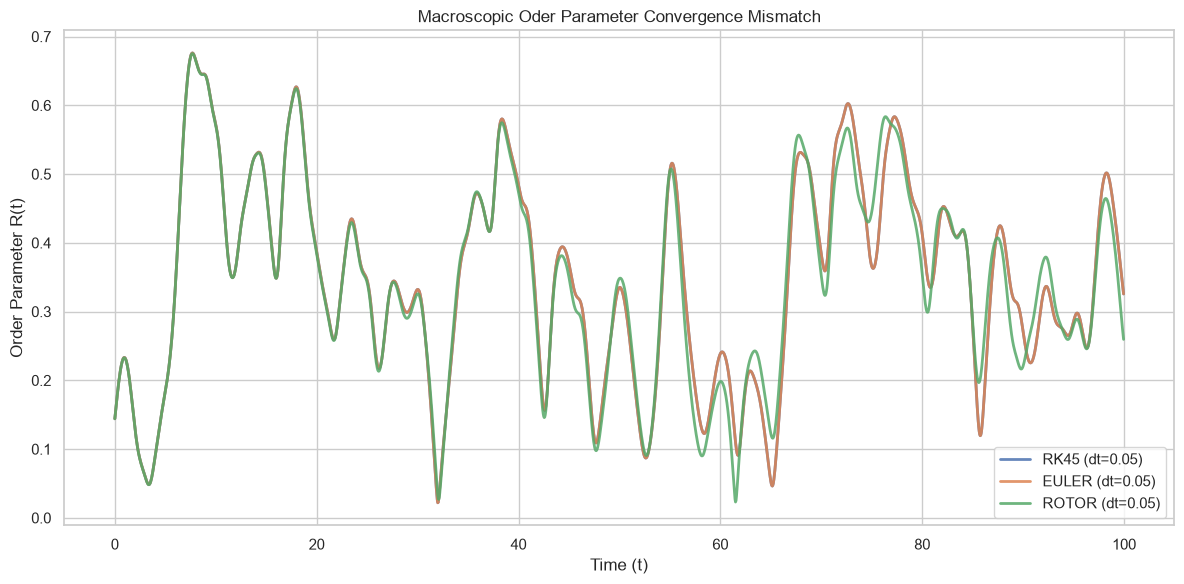

In [4]:
plt.figure()

from kuramoto.order_parameter import compute_order_parameter

for solver in solvers:
    data_path = f'data/benchmark/{solver}.npz'
    if os.path.exists(data_path):
        data = np.load(data_path)
        phases = data['theta']    # (T, N) phase array
        r = compute_order_parameter(phases)    # (T,) order parameter array
        t = np.arange(phases.shape[0]) * base_config['dt']

        plt.plot(t, r, label=f"{solver.upper()} (dt={base_config['dt']})", alpha=0.85, linewidth=2)

plt.xlabel('Time (t)')
plt.ylabel('Order Parameter R(t)')
plt.title('Macroscopic Oder Parameter Convergence Mismatch')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 🩺 Diagnosis Conservation Violations (`energy_conserved`)
Analyze the metadata `.json` generated by the framework's symmetry-tracking mode to confirm if energy or global phase invariants are drifting due to the fixed-step implementation.

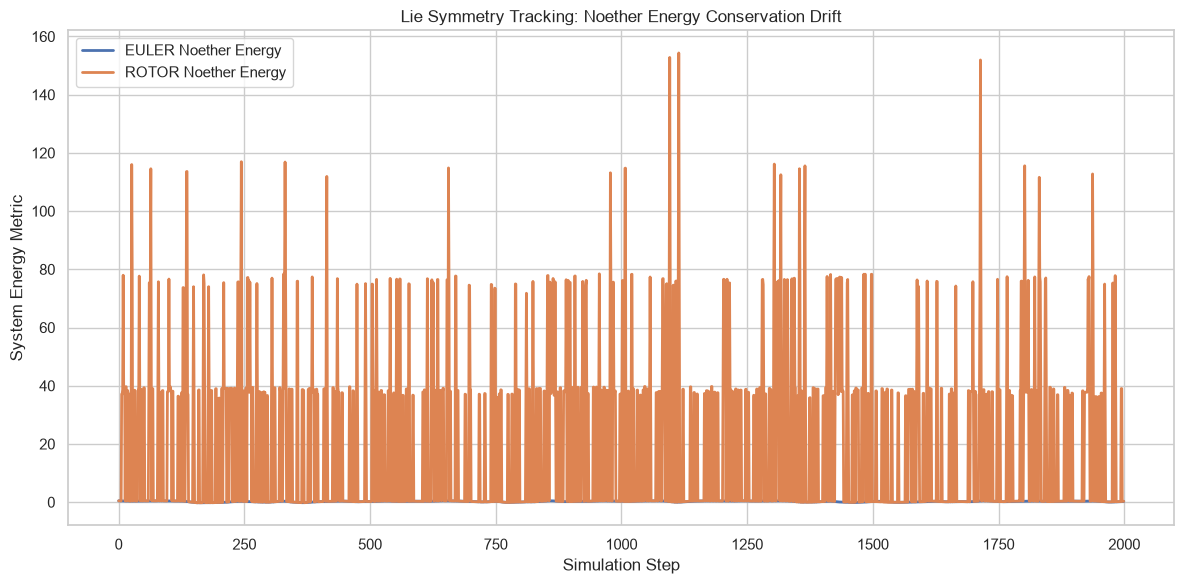

In [5]:
from kuramoto.order_parameter import track_lie_symmetries

plt.figure()

for solver in ['euler', 'rotor']:
    data_path = f'data/benchmark/{solver}.npz'
    if os.path.exists(data_path):
        data = np.load(data_path)
        if 'energy_conserved' in data:
            energy = data['energy_conserved']
        else:
            phases = data['theta']
            times = data['time'] if 'time' in data else np.arange(phases.shape[0]) * base_config['dt']
            states = {f"node_{i}": phases[:, i] for i in range(phases.shape[1])}
            metrics = track_lie_symmetries(states, times)
            energy = metrics.energy_conserved
            
        plt.plot(energy, label=f"{solver.upper()} Noether Energy", linewidth=2)

plt.xlabel('Simulation Step')
plt.ylabel('System Energy Metric')
plt.title('Lie Symmetry Tracking: Noether Energy Conservation Drift')
plt.legend()
plt.tight_layout()
plt.show()